In [24]:
import pandas as pd
pd.__version__

'2.3.3'

In [25]:
import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use('default')

In [26]:
import seaborn as sns
print(sns.__version__)

0.13.2


In [27]:
# 9.0. 
churn_data = pd.read_csv('data/churn.csv')
churn_data = churn_data.drop('RowNumber', axis=1)
churn_data.head()

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


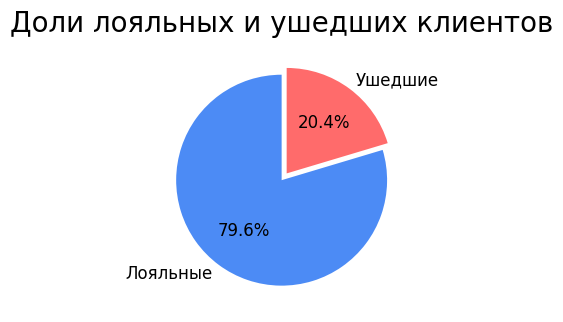

'Данные показывают, что подавляющее большинство клиентов (почти 80%) остаются лояльными банку, в то время как отток составляет 20,4%.'

In [6]:
# 9.1. Каково соотношение ушедших и лояльных клиентов? Покажите это на графике и дайте комментарий по соотношению.
# подсчитываем количество лояльных и ушедших клиентов
exited_counts = churn_data['Exited'].value_counts()
loyal   = exited_counts.get(0, 0)   # кол-во лояльных клиентов
churned = exited_counts.get(1, 0)   # кол-во ушедших клиентов

# строим график
plt.subplot(1, 2, 2)
plt.pie([loyal, churned],
        labels=[f'Лояльные', f'Ушедшие'],
        colors=['#4c8bf5', '#ff6b6b'],
        autopct='%1.1f%%',
        startangle=90,
        textprops={'fontsize': 12},
        explode=[0, 0.08]) 

plt.title('Доли лояльных и ушедших клиентов', fontsize=20, pad=12)

plt.tight_layout()
plt.show()

'''Данные показывают, что подавляющее большинство клиентов (почти 80%) остаются лояльными банку, в то время как отток составляет 20,4%.'''

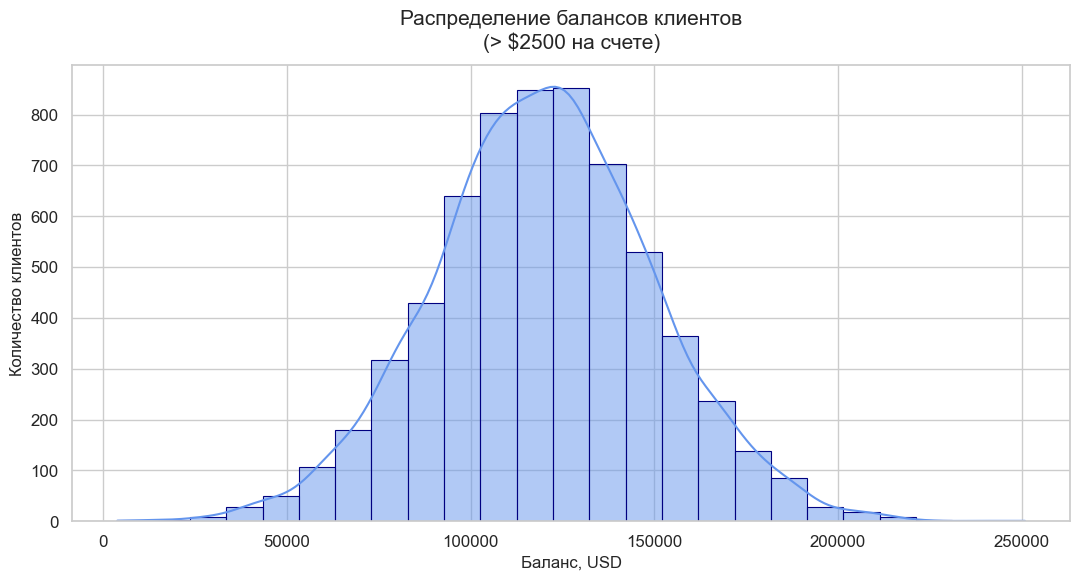

In [14]:
# 9.2 Постройте график, показывающий распределение баланса пользователей, у которых на счету больше 2 500 долларов. Опишите распределение и сделайте выводы.
# фильтруем(выбираем только тех, у кого больше 2,5к на счете)
balances = churn_data[churn_data['Balance'] > 2500]['Balance']

sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.1)

plt.figure(figsize=(11, 6))

# Строим график
sns.histplot(
    data=balances,
    bins=25,              
    kde=True,             # кривая плотности
    stat='count',
    color='cornflowerblue',
    edgecolor='navy',
    linewidth=0.8
)

plt.title('Распределение балансов клиентов\n(> $2500 на счете)', fontsize=15, pad=12)
plt.xlabel('Баланс, USD', fontsize=12)
plt.ylabel('Количество клиентов', fontsize=12)

plt.tight_layout()
plt.show()

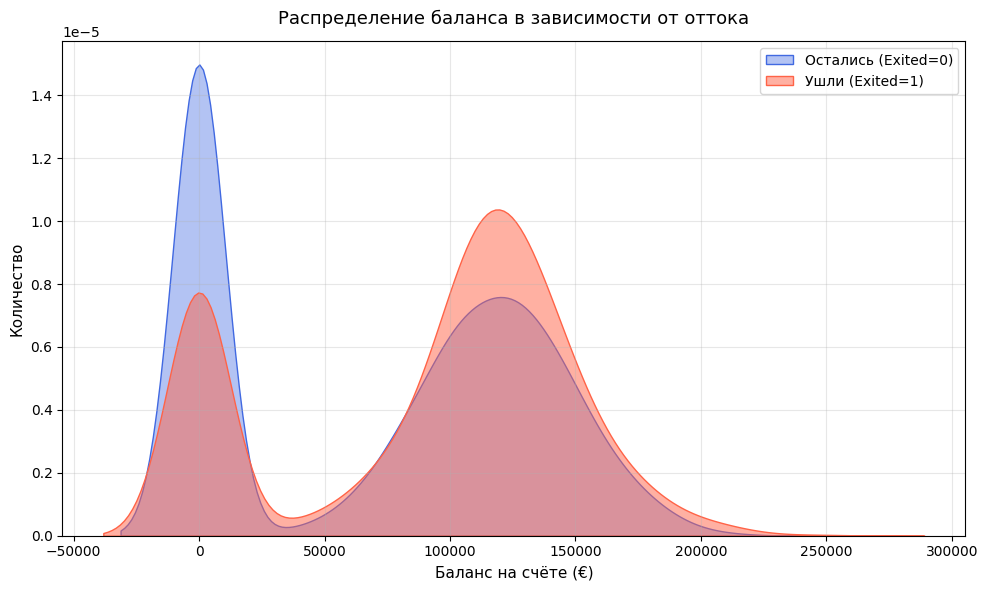

In [28]:
plt.figure(figsize=(10, 6))

# два графика плотности
sns.kdeplot(data=churn_data[churn_data['Exited'] == 0], x='Balance', 
            fill=True, color='royalblue', alpha=0.4, label='Остались (Exited=0)')
sns.kdeplot(data=churn_data[churn_data['Exited'] == 1], x='Balance', 
            fill=True, color='tomato', alpha=0.5, label='Ушли (Exited=1)')

plt.title('Распределение баланса в зависимости от оттока', fontsize=13, pad=12)
plt.xlabel('Баланс на счёте (€)', fontsize=11)
plt.ylabel('Количество', fontsize=11)
plt.legend(fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()